# Finite-Difference Playground

Validate one finite-difference C update by comparing stencil weights, symbolic code, and numerical samples.

Navigation: [Index](../index.ipynb) | Previous: [Boundary Conditions and Convergence](boundary_conditions_and_convergence.ipynb) | Next: [Wave Equation and C Code Generation](../3-wave_equation/wave_equation_and_c_codegen.ipynb)


## Learning Goals

- Experiment with one finite-difference derivative.
- Compare exact and numerical derivatives for a simple polynomial.
- Connect stencil coefficients to generated C code.

## Words for This Notebook

- **Playground:** a safe small example where you can change one choice and rerun.
- **Exact derivative:** the derivative computed by algebra.
- **Numerical derivative:** the derivative estimated from grid values.
- **Kernel:** a generated C routine that applies the formula repeatedly on grid data.

Use the code cells actively: first predict what should happen, then run the cell, then explain the output in plain language. This predict-run-explain pattern keeps the physics idea connected to the programming details.


## Validate One Kernel
The polynomial `x**4` has exact second derivative `12*x**2`. The fourth-order stencil should reproduce it at the sample point used here.

## Import SymPy for the Polynomial Test

These imports expose the NRPy and Python tools used in the next steps.


In [1]:
import sympy as sp


## Import Stencil and Codegen Helpers

These imports expose the NRPy registries and infrastructure writers used below.


In [2]:
import nrpy.c_codegen as ccg
import nrpy.finite_difference as fd
import nrpy.grid as grid
import nrpy.indexedexp as ixp
import nrpy.params as par


## Clear Playground Grid State

The reset clears tutorial-owned finite-difference helpers and fixes the order used in the next calculation.


In [3]:
grid.glb_gridfcs_dict.pop("uu", None)
for name in list(fd.FDFunctions_dict):
    if name.startswith("fdD"):
        fd.FDFunctions_dict.pop(name, None)
par.set_parval_from_str("Infrastructure", "BHaH")
par.set_parval_from_str("finite_difference::fd_order", 4)


## Compute the Chosen Stencil Weights

The printed coefficients define the finite-difference stencil.


In [4]:
coeffs, stencil = fd.compute_fdcoeffs_fdstencl("dDD00", 4)
print("stencil weights:")
for coeff, point in zip(coeffs, stencil):
    print(coeff, point)


stencil weights:
-1/12 [-2, 0, 0]
4/3 [-1, 0, 0]
-5/2 [0, 0, 0]
4/3 [1, 0, 0]
-1/12 [2, 0, 0]


## Plot the Stencil Weights

The signs and symmetry of the weights explain the second derivative: the center point is compared against nearby points on both sides.

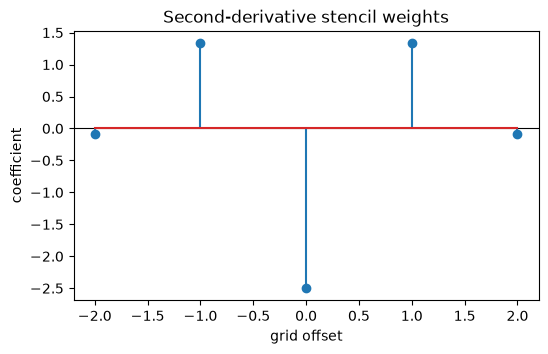

In [5]:
import matplotlib.pyplot as plt


offsets = [point[0] for point in stencil]
numeric_coeffs = [float(coeff) for coeff in coeffs]
plt.figure(figsize=(6, 3.5))
plt.axhline(0.0, color="black", linewidth=0.8)
plt.stem(offsets, numeric_coeffs)
plt.xlabel("grid offset")
plt.ylabel("coefficient")
plt.title("Second-derivative stencil weights")
plt.show()

## Test the Stencil on a Polynomial

A zero residual confirms that the symbolic expression matches the expected identity.


In [6]:
x0 = sp.Rational(3, 2)
dx = sp.Rational(1, 5)
stencil_value = sp.simplify(
    sum(coeffs[i] * (x0 + stencil[i][0] * dx) ** 4 / dx**2 for i in range(len(coeffs)))
)
exact_value = sp.diff(sp.Symbol("x") ** 4, sp.Symbol("x"), 2).subs(sp.Symbol("x"), x0)
print("stencil value:", stencil_value)
print("exact value:", exact_value)
print("residual:", sp.simplify(stencil_value - exact_value))
if sp.simplify(stencil_value - exact_value) != 0:
    raise RuntimeError("Expected the stencil residual to vanish.")


stencil value: 27
exact value: 27
residual: 0


## Emit a Generated Laplacian Assignment

NRPy's stored grid-field list records named fields and their roles in generated code.


In [7]:
uu = grid.register_gridfunctions("uu", group="EVOL")[0]
uu_dDD = ixp.declarerank2("uu_dDD", symmetry="sym01")
print("complete generated C update:")
print(
    ccg.c_codegen(
        uu_dDD[0][0],
        "laplacian_x0",
        include_braces=False,
        verbose=False,
        enable_fd_codegen=True,
        enable_fd_functions=True,
    )
)
print("complete helper code:")
print(fd.construct_FD_functions_prefunc())


complete generated C update:
/*
 * NRPy-Generated GF Access/FD Code, Step 1 of 2:
 * Read gridfunction(s) from main memory and compute FD stencils as needed.
 */
const REAL uu_i0m2 = in_gfs[IDX4(UUGF, i0-2, i1, i2)];
const REAL uu_i0m1 = in_gfs[IDX4(UUGF, i0-1, i1, i2)];
const REAL uu = in_gfs[IDX4(UUGF, i0, i1, i2)];
const REAL uu_i0p1 = in_gfs[IDX4(UUGF, i0+1, i1, i2)];
const REAL uu_i0p2 = in_gfs[IDX4(UUGF, i0+2, i1, i2)];
const REAL uu_dDD00 = fd_function_dDD00_fdorder4(uu,uu_i0m1,uu_i0m2,uu_i0p1,uu_i0p2,invdxx0);

/*
 * NRPy-Generated GF Access/FD Code, Step 2 of 2:
 * Evaluate SymPy expressions and write to main memory.
 */
laplacian_x0 = uu_dDD00;

complete helper code:
/**
 * Finite difference function for operator dDD00, with FD accuracy order 4.
 */
static NO_INLINE REAL fd_function_dDD00_fdorder4(const REAL FDPROTO, const REAL FDPROTO_i0m1, const REAL FDPROTO_i0m2, const REAL FDPROTO_i0p1,
                                                 const REAL FDPROTO_i0p2, const REAL i

The residual check ties the displayed stencil to an exact polynomial derivative. The generated C update and helper code show the same coefficients in the form used inside C loops.


## Learning Check

After the notebook works once, change the finite-difference order and predict how the stencil width changes before rerunning the coefficient cell.


## Continue to Wave-Equation Codegen
- [C Code Generation](../1-intro/c_codegen.ipynb)
- [Finite Differences](../1-intro/finite_difference.ipynb)
- [Wave Equation and C Code Generation](../3-wave_equation/wave_equation_and_c_codegen.ipynb)
